In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [196]:
df = pd.read_csv("D:\\CreditCard_Fraud_Detection\\Data\\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [198]:
#no null values but duplicates so have to remove

df.drop_duplicates(inplace=True)

In [199]:
df.duplicated().sum()

np.int64(0)

In [200]:
#total 283726 samples after removing duplicates and 30 features

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [201]:
df['Class'].value_counts()

# 0 --> normal
# 1 --> fraud

# you can see how imbalanced the data is the fraud is approx 0.17% which is very low

Class
0    283253
1       473
Name: count, dtype: int64

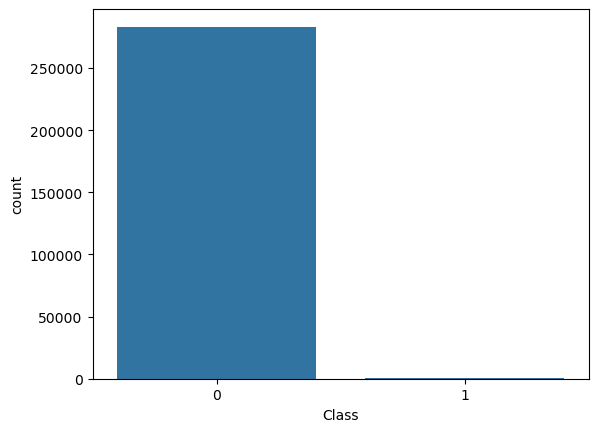

In [202]:
#visualize
sns.countplot(x=df['Class'])
plt.show()

In [203]:
#NOW LETS UNDERSTAND THE DATA

# what are V1,V2........V28

# These are PCA (principle component analysis [scaled]) transformed features , come from technique known as PCA

# Why these are PCA transformed??

# Real credit card transaction data contains sensitive information, like:
# transaction location
# merchant type
# card number patterns

# So PCA is used to 
# Protect user privacy
# Hide sensitive information
# Still keep patterns needed for fraud detection

# PCA converts original variables into new variables called principal components.

# they always have a pattern it hides in a way that pattern remains 

# PCA are always scaled so no need to scale them  (b/w -1,0,1+)

In [204]:
from sklearn.preprocessing import StandardScaler


scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df["Amount"] = scaler_amount.fit_transform(df["Amount"].values.reshape(-1,1))
df["Time"] = scaler_time.fit_transform(df["Time"].values.reshape(-1,1))


In [205]:
features = ["Time","Amount","V1","V2","V3","V4","V5"]
x = df[features]
y = df['Class']

In [206]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
# stratify=y ensures same fraud ratio in both sets itna imbalanced hai ki kya pta training me koi fraud data na aaye aur test me aajaye to model to hmara train ni hua ki fraud kaise detect kre will fail miserably
# yaa phir training me saare fraud aajaye (worst case both can't be trained better)
# stratify ensures equal fraud ratio in both train and test

In [207]:
from sklearn.linear_model import LogisticRegression

model =LogisticRegression()

model.fit(x_train,y_train)

LogisticRegression()

In [208]:
y_pred = model.predict(x_test)

In [209]:
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score

#since this data is imbalanced accuracy is not good metrics to measure 

print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

[[56641    10]
 [   63    32]]
0.9987135657138829
0.7619047619047619
0.3368421052631579


In [210]:
# now we know fraud cases were very less so our model is not able to catch many fraud cases(catch 56 and 39 cannot) 
# because it can't find pattern as fraud data is very less

# so our recall score is coming very less means our FN is very high
# means our model is saying that 39 are normal cases(0) but actually they are fraud(1)
# which is fatal very bad model it should be minimum

# STEPS TO INCREASE THE RECALL SCORE (MIN FN) 

In [211]:
# 1. using balanced class weights which gives importance to both fraud and normal samples
# 2. undersampling reducing normal samples bring equal to fraud ones
# 3. oversampling duplicating the fraud samples
# 4. SMOTE(synthetic minority oversampling technique) --> best method generates synthetic fraud samples

In [212]:
# we will see three cases class weights, undersampling and smote and see recall score for all

In [213]:
model2 = LogisticRegression(
    class_weight='balanced',
    max_iter=20000
)

model2.fit(x_train,y_train)
y_pred_cl = model2.predict(x_test)

In [214]:
print(confusion_matrix(y_test,y_pred_cl))
print(accuracy_score(y_test,y_pred_cl))
print(precision_score(y_test,y_pred_cl))
print(recall_score(y_test,y_pred_cl))

[[53669  2982]
 [   12    83]]
0.9472385718817186
0.027079934747145186
0.8736842105263158


In [215]:
# 87% it can detect fraud cases
# now this is better however precision becomes very low but that doesn't concern

# why this doesn't concern 

# think if model said normal but was fraud all money gone (loss)
# if model said fraud but was normal, account will get froze and relaesed once confirmed by user no loss of money

In [216]:
# Lets see undersampling

fraud = df[df['Class']==1]
normal = df[df['Class']==0]

normal_sample = normal.sample(len(fraud), random_state=42)
balanced_df = pd.concat([fraud, normal_sample])
normal_sample.shape

(473, 31)

In [217]:
fraud.shape

(473, 31)

In [218]:
x_u = balanced_df[features]
y_u = balanced_df['Class']

x_trainu,x_testu,y_trainu,y_testu = train_test_split(x_u,y_u,test_size=0.2,random_state=42)

undersample_model = LogisticRegression()

undersample_model.fit(x_trainu,y_trainu)

LogisticRegression()

In [219]:
y_pred_u = undersample_model.predict(x_testu)

print(confusion_matrix(y_testu,y_pred_u))
print(accuracy_score(y_testu,y_pred_u))
print(precision_score(y_testu,y_pred_u))
print(recall_score(y_testu,y_pred_u))

[[96  6]
 [ 3 85]]
0.9526315789473684
0.9340659340659341
0.9659090909090909


In [220]:
# now SMOTE method

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_resample,y_resample = smote.fit_resample(x_train,y_train)

y_resample.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [221]:

model_smot = LogisticRegression(max_iter=2000)
model_smot.fit(x_resample,y_resample)

LogisticRegression(max_iter=2000)

In [222]:
y_pred_smot = model_smot.predict(x_test)

In [223]:
print(confusion_matrix(y_test,y_pred_smot))
print(accuracy_score(y_test,y_pred_smot))
print(precision_score(y_test,y_pred_smot))
print(recall_score(y_test,y_pred_smot))

[[53714  2937]
 [   12    83]]
0.948031579318366
0.02748344370860927
0.8736842105263158


### COMPARISION TABLE

| Method            | Accuracy | Precision | Recall    |
| ----------------- | -------- | --------- | --------- |
| Baseline Logistic | 0.999    | 0.84      | 0.58      |
| Class Weight      | 0.975    | 0.056     | 0.87      |
| Undersampling     | 0.978    | 0.988     | 0.965     |
| SMOTE             | 0.970    | 0.05      | 0.87      |


In [224]:
# so i think our Undersampling is much better model

In [225]:
import pickle
pickle.dump(undersample_model, open("fraud_model.pkl","wb"))
pickle.dump(scaler_amount, open("scaler_amount.pkl","wb"))
pickle.dump(scaler_time, open("scaler_time.pkl","wb"))

In [ ]:
feature_names = x.columns
coefficients = model.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance = importance.sort_values(by="Coefficient", ascending=False)

importance.head(10)
# v4 more --> fraud more

,Feature,Coefficient
5,V4,0.891552
3,V2,0.210998
6,V5,0.182822
2,V1,0.134976
1,Amount,0.054581
0,Time,-0.236479
4,V3,-0.481300


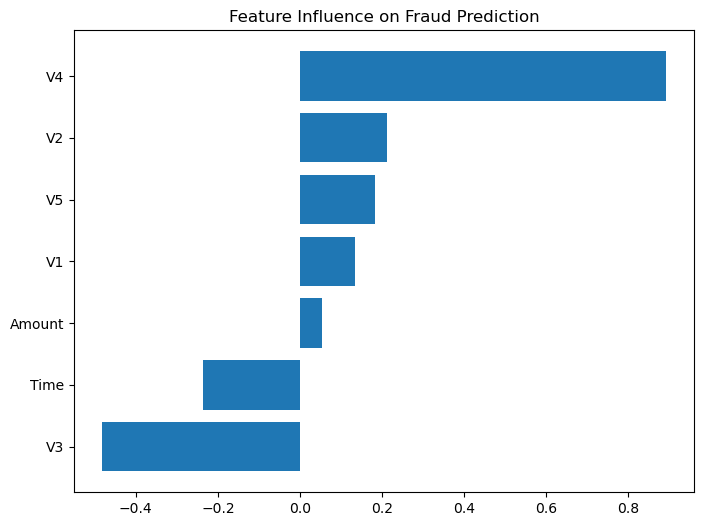

In [227]:
importance_sorted = importance.sort_values(by="Coefficient")

plt.figure(figsize=(8,6))
plt.barh(importance_sorted["Feature"], importance_sorted["Coefficient"])
plt.title("Feature Influence on Fraud Prediction")
plt.show()